Step 1

1. 
- Student Performance Dataset (student-por.csv, Portuguese language course).
- https://archive.ics.uci.edu/dataset/320/student+performance

2. 
Regulated Domain: Education

3.
Observations (Rows): 649 observation

4.
Variables (Columns): 33 total variables

5.
- G3_pass (G3 - Final Grade): A binary variable where 1 = Pass ( G3 >= 10) and 0 = Fail ( G3 < 10 ). This measures final course completion
- G2_pass (G2 - Second Period Grade): A binary variable where 1 = Pass ( G2 >= 10) and 0 = Fail ( G2 < 10 ). This measures mid-year academic performance.


6.
- Count: 3 variables[cite: 4].
- Variables:
- sex: Student's sex (F - female or M - male)
- age: Student's age (numeric: 15 to 22 years old)
- address: Student's home address type (U - urban or R - rural)

7.
- sex: Title IX of the Education Amendments of 1972 (prohibits sex-based discrimination in education programs or activities receiving federal financial assistance).
- age: The Age Discrimination Act of 1975 (prohibits discrimination on the basis of age in programs or activities receiving federal financial assistance).
- address (Urban/Rural): Title VI of the Civil Rights Act of 1964 (under the lens of geography acting as a proxy for socioeconomic status or race in educational access and public accommodation).



Step 2

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('student-por.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [5]:
# create pass columns
df['G2_pass'] = (df['G2'] >= 10).astype(int)
df['G3_pass'] = (df['G3'] >= 10).astype(int)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,G2_pass,G3_pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,4,0,11,11,1,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,2,9,11,11,1,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,6,12,13,12,1,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,0,14,14,14,1,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,0,11,13,13,1,1


2.1

Protected class & subgroup

Sex: Female, Male
Age: 15, 16, 17, 18, 19, 20, 21, 22

2.2

- Sex
female : 0
male : 1

- Age
15: 0
16: 1
17: 2
18: 3
19: 4
20: 5
21: 6
22: 7

2.3

Chosen protected classes: Sex, Age


In [12]:
# 2.4

protected_class = ['sex', 'age']
dep_val = ['G2_pass', 'G3_pass']

for pc in protected_class:
    for dv in dep_val:
        table = pd.crosstab(
            df[pc], df[dv],)
        display(table)

G2_pass,0,1
sex,,
F,72,311
M,73,193


G3_pass,0,1
sex,,
F,50,333
M,50,216


G2_pass,0,1
age,,
15,14,98
16,33,144
17,43,136
18,38,102
19,15,17
20,1,5
21,0,2
22,1,0


G3_pass,0,1
age,,
15,12,100
16,22,155
17,28,151
18,27,113
19,10,22
20,0,6
21,0,2
22,1,0


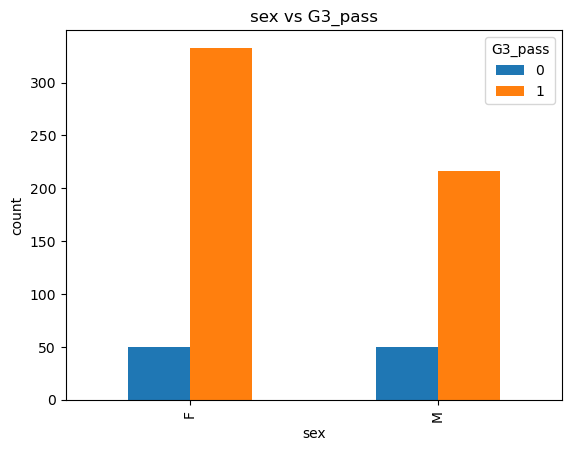

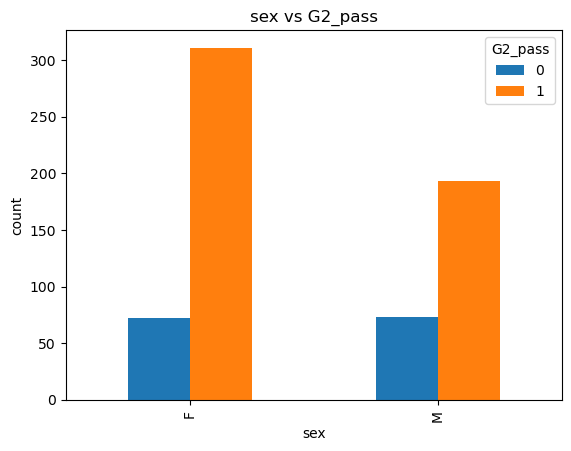

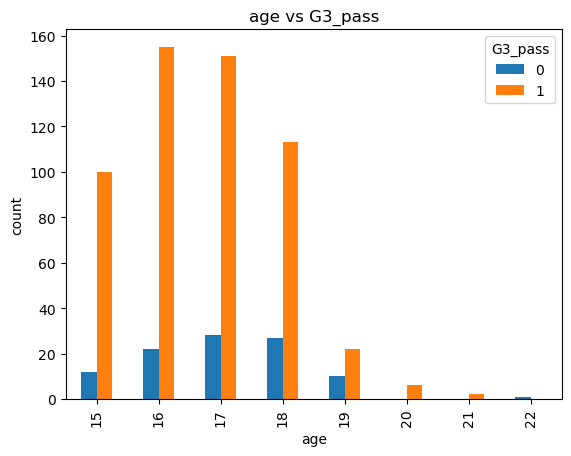

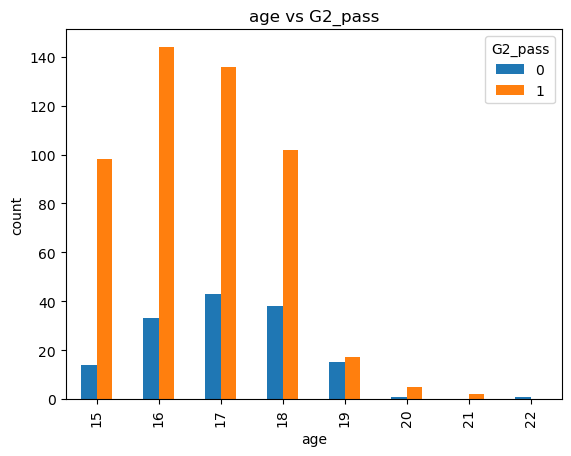

In [14]:
# 2.5

pd.crosstab(df['sex'], df['G3_pass']).plot(kind='bar')
plt.title('sex vs G3_pass')
plt.ylabel('count')
plt.show()

pd.crosstab(df['sex'], df['G2_pass']).plot(kind='bar')
plt.title('sex vs G2_pass')
plt.ylabel('count')
plt.show()

pd.crosstab(df['age'], df['G3_pass']).plot(kind='bar')
plt.title('age vs G3_pass')
plt.ylabel('count')
plt.show()

pd.crosstab(df['age'], df['G2_pass']).plot(kind='bar')
plt.title('age vs G2_pass')
plt.ylabel('count')
plt.show()


Step 3

3.1
- Sex
Priviledged: Female ( because higher pass rate)
Unpriviledged: Male

- Age
Priviledged: age <= 17 ( because higher pass rate)
Unpriviledged: age >= 18